# Laboratorio 3: Regresión Lineal Multivariable, Regresión Polinómica y Ecuación de la Normal
**Nombre:** Plaza López Cesar Manuel  
**Dataset:** FIFA 22 Players (`players_22.csv`)  
**Objetivo:** Estimar el valor de mercado en euros (`value_eur`) de jugadores de fútbol en base a sus características físicas y habilidades técnicas ($n = 13$, $m > 17,000$).

### 1.- Importar Librerías

In [3]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd
# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

### 2.- Carga del Dataset y limpieza de datos

In [4]:
# 1. Cargar el dataset de FIFA 22
df = pd.read_csv('players_22.csv', low_memory=False)

# 2. Selección de 13 características numéricas (n >= 10) y la etiqueta y
feature_cols = [
    'overall', 'potential', 'age', 'height_cm', 'weight_kg', 
    'pace', 'shooting', 'passing', 'dribbling', 'defending', 
    'physic', 'skill_moves', 'international_reputation'
]
target_col = 'value_eur'

# 3. Filtrar y eliminar valores nulos (NaN)
df_clean = df[feature_cols + [target_col]].dropna()

# 4. Extracción de matrices NumPy
X_raw = df_clean[feature_cols].values
y = df_clean[target_col].values
m = y.size
n = X_raw.shape[1]

print("CARGA DE DATOS EXITOSA")
print(f"Número de ejemplos de entrenamiento (m): {m}")
print(f"Número de características (n): {n}")
print(f"Forma de X_raw: {X_raw.shape}")
print(f"Forma de y: {y.shape}")

CARGA DE DATOS EXITOSA
Número de ejemplos de entrenamiento (m): 17041
Número de características (n): 13
Forma de X_raw: (17041, 13)
Forma de y: (17041,)


### 3.- Funciones Matemáticas Base

In [5]:
def featureNormalize(X):
    """
    Normaliza las características de X usando Z-score.
    Devuelve la matriz normalizada, la media (mu) y la desviación estándar (sigma).
    """
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    
    # Previene la división por cero en caso de desviaciones estándar nulas
    sigma[sigma == 0] = 1
    
    X_norm = (X - mu) / sigma
    return X_norm, mu, sigma

def computeCostMulti(X, y, theta):
    """
    Calcula el costo J(theta) para regresión lineal múltiple en forma vectorizada.
    """
    m = y.shape[0]
    h = np.dot(X, theta)
    J = (1 / (2 * m)) * np.sum(np.square(h - y))
    return J

def gradientDescentMulti(X, y, theta, alpha, num_iters):
    """
    Ejecuta el descenso por el gradiente vectorizado para optimizar theta.
    """
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

def normalEqn(X, y):
    """
    Calcula la solución analítica exacta de theta mediante la Ecuación de la Normal.
    Se utiliza np.linalg.pinv (pseudoinversa) para asegurar estabilidad numérica.
    """
    theta = np.zeros(X.shape[1])
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)
    return theta

print("FUNCIONES BASE CARGADAS CORRECTAMENTE")

FUNCIONES BASE CARGADAS CORRECTAMENTE


### Modelo 1 - Regresión Lineal Multivariable

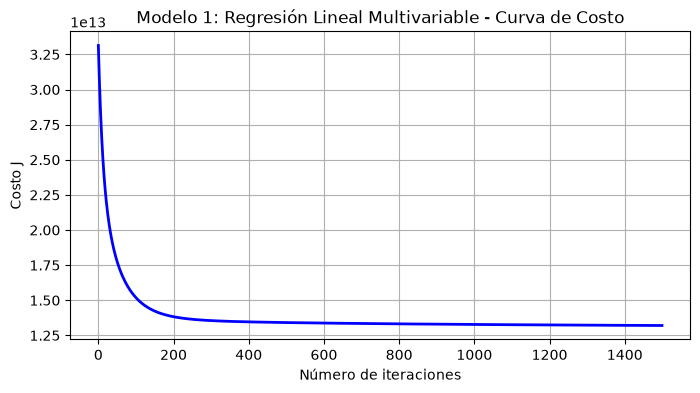

MODELO 1 COMPLETADO
Costo inicial J(theta): 33,136,223,303,216.81
Costo final alcanzado J(theta): 13,203,676,113,083.73


In [6]:
# 1. Normalización de características y adición de la columna de unos (x0 = 1)
X_norm1, mu1, sigma1 = featureNormalize(X_raw)
X_m1 = np.concatenate([np.ones((m, 1)), X_norm1], axis=1)

# 2. Configuración de hiperparámetros
alpha1 = 0.01
num_iters1 = 1500
theta1 = np.zeros(X_m1.shape[1])

# 3. Entrenamiento con Descenso por el Gradiente
theta1, J_history1 = gradientDescentMulti(X_m1, y, theta1, alpha1, num_iters1)

# 4. Gráfica de convergencia del costo J(theta)
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history1)), J_history1, lw=2, color='blue')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Modelo 1: Regresión Lineal Multivariable - Curva de Costo')
pyplot.grid(True)
pyplot.show()

# 5. Muestra de resultados
print("MODELO 1 COMPLETADO")
print(f"Costo inicial J(theta): {J_history1[0]:,.2f}")
print(f"Costo final alcanzado J(theta): {J_history1[-1]:,.2f}")

### 3.- MODELO 2 - Regresión Polinómica

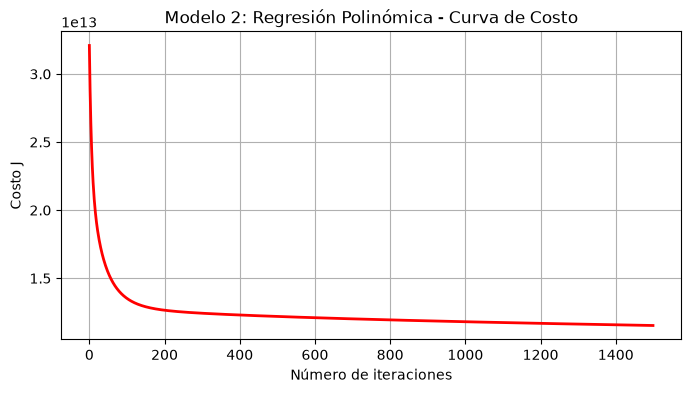

=== MODELO 2 COMPLETADO ===
Costo inicial J(theta): 32,090,047,725,861.83
Costo final alcanzado J(theta): 11,530,826,071,444.85


In [7]:
# 1. Creación de características polinómicas (X y X^2)
X_poly = np.concatenate([X_raw, X_raw ** 2], axis=1)

# 2. Normalización de las características polinómicas y adición de x0 = 1
X_poly_norm, mu_poly, sigma_poly = featureNormalize(X_poly)
X_m2 = np.concatenate([np.ones((m, 1)), X_poly_norm], axis=1)

# 3. Configuración de hiperparámetros
alpha2 = 0.01
num_iters2 = 1500
theta2 = np.zeros(X_m2.shape[1])

# 4. Entrenamiento con Descenso por el Gradiente
theta2, J_history2 = gradientDescentMulti(X_m2, y, theta2, alpha2, num_iters2)

# 5. Gráfica de convergencia del costo J(theta)
pyplot.figure(figsize=(8, 4))
pyplot.plot(np.arange(len(J_history2)), J_history2, lw=2, color='red')
pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Modelo 2: Regresión Polinómica - Curva de Costo')
pyplot.grid(True)
pyplot.show()

# 6. Muestra de resultados
print("=== MODELO 2 COMPLETADO ===")
print(f"Costo inicial J(theta): {J_history2[0]:,.2f}")
print(f"Costo final alcanzado J(theta): {J_history2[-1]:,.2f}")


### 4.- MODELO 3 - Ecuación de la normal


In [9]:
# 1. Matriz de características polinómicas con la columna de unos (x0 = 1) SIN normalizar
X_m3 = np.concatenate([np.ones((m, 1)), X_poly], axis=1)

# 2. Cálculo de Theta usando la Ecuación de la Normal
theta3 = normalEqn(X_m3, y)

# 3. Cálculo del costo J(theta) para el modelo analítico
costo_m3 = computeCostMulti(X_m3, y, theta3)

print("MODELO 3 COMPLETADO")
print(f"Costo J(theta) obtenido con Ecuación de la Normal: {costo_m3:,.2f}")

MODELO 3 COMPLETADO
Costo J(theta) obtenido con Ecuación de la Normal: 6,636,935,774,887.28


### 5.- VALIDACIÓN Y EVALUACIÓN DE 100 PREDICCIONES

In [10]:
num_pred = 100
X_test_raw = X_raw[:num_pred]
y_test_real = y[:num_pred]

# 1. Inferencia Modelo 1 (Regresión Lineal Multivariable)
X_test1_norm = (X_test_raw - mu1) / sigma1
X_test1_b = np.concatenate([np.ones((num_pred, 1)), X_test1_norm], axis=1)
pred_m1 = np.dot(X_test1_b, theta1)

# 2. Inferencia Modelo 2 (Regresión Polinómica - Descenso Gradiente)
X_test_poly = np.concatenate([X_test_raw, X_test_raw ** 2], axis=1)
X_test2_norm = (X_test_poly - mu_poly) / sigma_poly
X_test2_b = np.concatenate([np.ones((num_pred, 1)), X_test2_norm], axis=1)
pred_m2 = np.dot(X_test2_b, theta2)

# 3. Inferencia Modelo 3 (Ecuación de la Normal)
X_test3_b = np.concatenate([np.ones((num_pred, 1)), X_test_poly], axis=1)
pred_m3 = np.dot(X_test3_b, theta3)

# Mostrar una tabla con las primeras 10 predicciones para inspección visual
print(f"{'N°':<3} | {'Valor Real (€)':<15} | {'Reg. Multivariable':<18} | {'Reg. Polinómica':<18} | {'Ecuación Normal':<18}")
print("-" * 80)
for i in range(10):
    print(f"{i+1:<3} | €{y_test_real[i]:<14,.0f} | €{pred_m1[i]:<17,.0f} | €{pred_m2[i]:<17,.0f} | €{pred_m3[i]:<17,.0f}")

# Evaluación del Error Cuadrático Medio en la muestra de 100 predicciones
rmse_m1 = np.sqrt(np.mean((pred_m1 - y_test_real)**2))
rmse_m2 = np.sqrt(np.mean((pred_m2 - y_test_real)**2))
rmse_m3 = np.sqrt(np.mean((pred_m3 - y_test_real)**2))

print("\n" + "="*60)
print("ERROR PROMEDIO REAL (RMSE) EN LAS 100 PREDICCIONES")
print("="*60)
print(f"Modelo 1 (Lineal Multivariable):   €{rmse_m1:,.2f}")
print(f"Modelo 2 (Regresión Polinómica):   €{rmse_m2:,.2f}")
print(f"Modelo 3 (Ecuación de la Normal): €{rmse_m3:,.2f}")

N°  | Valor Real (€)  | Reg. Multivariable | Reg. Polinómica    | Ecuación Normal   
--------------------------------------------------------------------------------
1   | €78,000,000     | €52,830,563        | €71,797,920        | €96,742,408       
2   | €119,500,000    | €53,408,912        | €71,235,225        | €93,723,909       
3   | €45,000,000     | €51,680,318        | €69,095,495        | €87,695,549       
4   | €129,000,000    | €53,960,401        | €72,631,676        | €91,600,442       
5   | €125,500,000    | €43,467,293        | €53,058,273        | €72,855,681       
6   | €194,000,000    | €47,324,250        | €57,198,430        | €83,678,081       
7   | €129,500,000    | €43,410,719        | €52,492,571        | €70,480,851       
8   | €100,000,000    | €42,685,331        | €50,478,551        | €66,998,954       
9   | €66,000,000     | €41,076,587        | €48,880,874        | €64,134,827       
10  | €104,000,000    | €43,050,660        | €51,601,883        | €66